# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Halia
* Username: hatela
* Student number: S6250890
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

Radii: [ 0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55
  0.6   0.65  0.7   0.75  0.8   0.85  0.9   0.95  1.    1.05  1.1   1.15
  1.2   1.25  1.3   1.35  1.4   1.45  1.5   1.55  1.6   1.65  1.7   1.75
  1.8   1.85  1.9   1.95  2.    2.05  2.1   2.15  2.2   2.25  2.3   2.35
  2.4   2.45  2.5   2.55  2.6   2.65  2.7   2.75  2.8   2.85  2.9   2.95
  3.    3.05  3.1   3.15  3.2   3.25  3.3   3.35  3.4   3.45  3.5   3.55
  3.6   3.65  3.7   3.75  3.8   3.85  3.9   3.95  4.    4.05  4.1   4.15
  4.2   4.25  4.3   4.35  4.4   4.45  4.5   4.55  4.6   4.65  4.7   4.75
  4.8   4.85  4.9   4.95  5.    5.05  5.1   5.15  5.2   5.25  5.3   5.35
  5.4   5.45  5.5   5.55  5.6   5.65  5.7   5.75  5.8   5.85  5.9   5.95
  6.    6.05  6.1   6.15  6.2   6.25  6.3   6.35  6.4   6.45  6.5   6.55
  6.6   6.65  6.7   6.75  6.8   6.85  6.9   6.95  7.    7.05  7.1   7.15
  7.2   7.25  7.3   7.35  7.4   7.45  7.5   7.55  7.6   7.65  7.7   7.75
  7.8   7.85  7.9   7.95  8.    8.05  8.1   

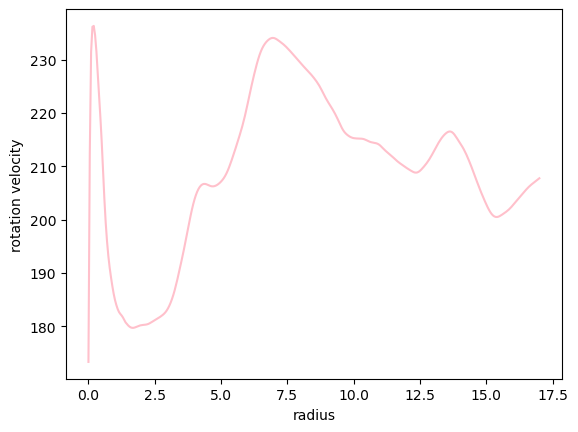

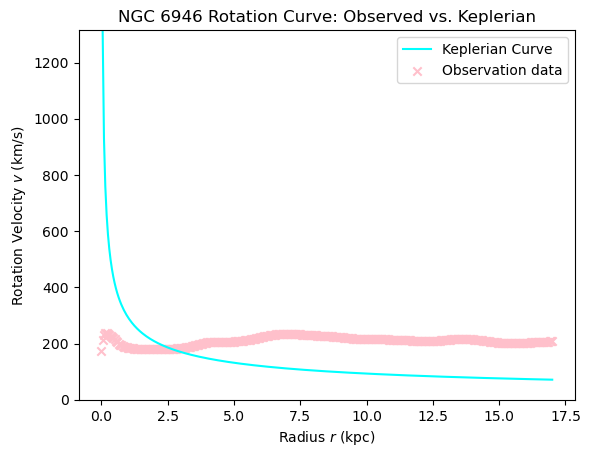

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

radii, velocities = np.loadtxt('rotcur.dat.txt', unpack=True)
print(f"Radii: {radii}")
print()
print(f"Rotation velocities: {velocities}")

# Plot
plt.plot(radii, velocities, color='pink')
plt.xlabel('radius')
plt.ylabel('rotation velocity')
plt.show()

print() 

# Keplerian rotation curve
kpc_to_m = 3.086*10**19
radii_m = radii * kpc_to_m
M = (2*10**10) * (2*10**30)
v_ms = np.sqrt(G*M / radii_m[1:]) # Start with index 1 to avoid division by 0
v_ks = v_ms / 1000

# Prepare matrix to save it using np.vstack and transpose
M = np.vstack((radii[1:], v_ks)).T
np.savetxt('keplerian_curve.txt', M)

# Loading data and final plot
radii_kep, v_ks = np.loadtxt('keplerian_curve.txt', unpack=True)
plt.plot(radii_kep, v_ks, color='cyan', label='Keplerian Curve')
plt.scatter(radii, velocities, marker='x', color='pink', label='Observation data')

# Forcing the lower limit of the y-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
max_v = np.max(v_ks)
plt.ylim(0, max_v)

# Relevant info annotations:
plt.xlabel(r'Radius $r$ (kpc)')
plt.ylabel(r'Rotation Velocity $v$ (km/s)')
plt.title('NGC 6946 Rotation Curve: Observed vs. Keplerian')
plt.legend()
plt.show()


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

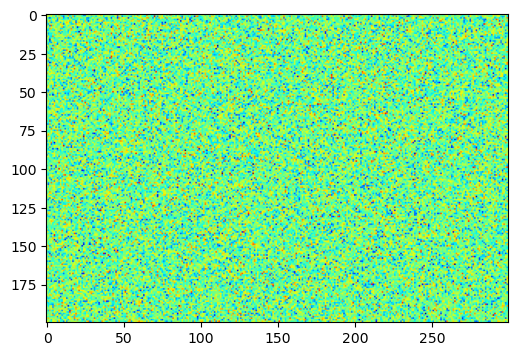

Slice Mean: -0.020411028406775503
Slice Sandard Deviation: 0.9958619441946779


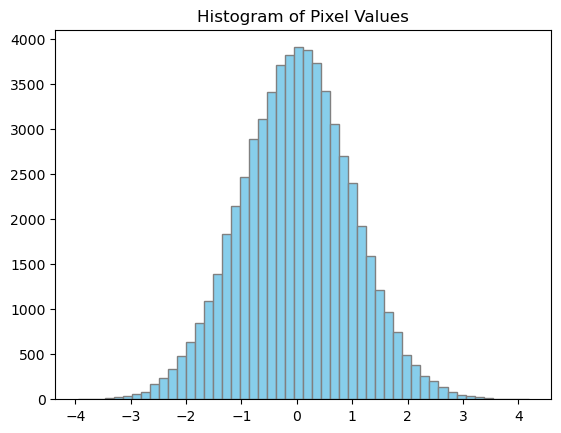

I recognize the Normal (Gaussian) Distribution :)


In [4]:
data = np.random.normal(0, 1, size=(200, 300)) # 200 rows (height), 300 columns (width)

plt.figure(figsize=(8,4))
plt.imshow(data, cmap='jet')
plt.show()

# Small 2D slice
slice_2d = data[40:70, 40:70]
mean = np.mean(slice_2d)
stdv = np.std(slice_2d)

print(f"Slice Mean: {mean}")
print(f"Slice Sandard Deviation: {stdv}")

# The values obtained for mean(=0) and standard deviation(=1) are what was expected with a slight deviation because a 30*30 slice is a random sample. 

# Histogram 
plt.figure()
flattened_data = np.ravel(data)
plt.hist(flattened_data, bins=50, color='skyblue', edgecolor='grey')
plt.title("Histogram of Pixel Values")
plt.show()

print("I recognize the Normal (Gaussian) Distribution :)")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

The area of the ellipse is: 18.8496
The perimeter of the ellipse is: 15.8654
Center: (0, 0)  Semi-major and semi-minor axes: 3 and 2  Angle: 45 deg



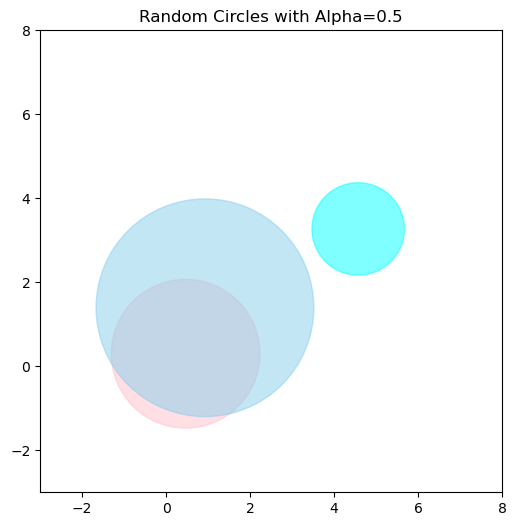

In [6]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

# Copied code:
class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)

      # store attributes
      self.a = semi_major
      self.b = semi_minor
      self.center = (xc, yc) 
      self.angle_deg = position_angle 
   
    # method that calculates and returns the area of the ellipse
    def area_ellipse(self):
        A = np.pi * self.a * self.b
        return A

    # method that calculates and returns the perimeter of the ellipse
    def perimeter_ellipse(self):
        term_1 = 3 * (self.a + self.b)
        term_2 = np.sqrt((3 * self.a + self.b) * (self.a + 3 * self.b))
        P = np.pi * (term_1 - term_2)
        return P

    # string method
    def __str__(self):
        s = f"Center: {self.center}  Semi-major and semi-minor axes: {self.a} and {self.b}  Angle: {self.angle_deg} deg"
        return s

# Example: creation of an ellipse
my_ellipse = AstroEllipse(0, 0, 3, 2, 0)
# call methods and store results
area_result = my_ellipse.area_ellipse()
perimeter_result = my_ellipse.perimeter_ellipse()

print(f"The area of the ellipse is: {area_result:.4f}")
print(f"The perimeter of the ellipse is: {perimeter_result:.4f}")

# Demonstrate string method:
test_ellipse = AstroEllipse (0, 0, 3, 2, 45)
print (test_ellipse)

print()

# Creating MyCircle class
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        
        # The position angle is 0 because a circle looks the same rotated
        super().__init__(xc, yc, radius, radius, 0, **args) # radius twice because for a circle, a = b = radius

# Plot with three circles
fig, ax = plt.subplots(figsize=(6,6))

# Define colors in a list (-> to use a for loop)
colors = ['pink', 'skyblue', 'cyan']

# Create three random circles using a loop:
for i in range(3):
    # random coordinates (x,y) -> origin of circles and random radii
    rx = np.random.uniform(0,5) 
    ry = np.random.uniform(0,5)
    rad = np.random.uniform (1, 3) # random radii of circles

    # Create one circle per loop, using color at index i
    c = MyCircle(rx, ry, rad, color=colors[i], alpha=0.5)
   
    ax.add_patch(c)  # This "adds" the created circle

# Formatting
ax.set_xlim(-3, 8) # To meke sure that we can see the circles
ax.set_ylim(-3, 8)
ax.set_aspect('equal') # Keep circles circular, not squashed
plt.title("Random Circles with Alpha=0.5")
plt.show()
    

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

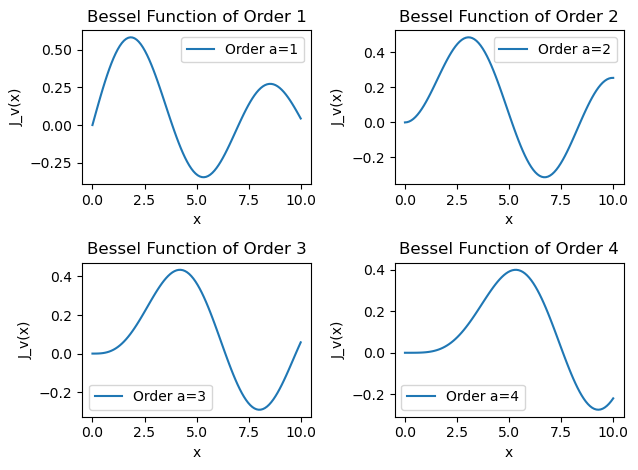

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# Set up data
x = np.linspace(0,10,100)
orders = [1,2,3,4]

fig, ax = plt.subplots(nrows=2, ncols=2) # This creates the Figure (canvas) and a 2x2 array of Axes (subplots)

# Flatten axes array: we do this to be able to pair each order (a) with a subplot.
# (in the bessel funct the order determines the specific shape and "frequency" of the wave-like solution)
flat_ax = ax.ravel()

for a, ax in zip(orders, flat_ax):
    y = jv(a, x) # Bessel function for the current order (a)

    # Plotting
    ax.plot(x, y, label=f'Order a={a}')
    ax.set_title(f'Bessel Function of Order {a}')
    ax.set_xlabel('x')
    ax.set_ylabel('J_v(x)')
    ax.legend()

fig.tight_layout() # if we don't use this the title's of the bottom graphs overlap with the top graphs

# Save as a transparent PNG
fig.savefig('bessel.png', transparent=True)

plt.show()
    

https://jupyterhub.astro.rug.nl/hub/user-redirect/lab/tree/PROGNUM-repo/Task5/bessel.png

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

[18.49, 35.48, 35.48, 11.34, 7.12, 9.82, 23.66, 44, 66.7, 52.4, 55, 25.6, 26.19]
[0.3, 2.2, 3.0, 1.2, 0.4, 0.3, 2.3, 4.0, 5.3, 5.2, 6.1, 3.2, 2.8]
[2094.75, 2320.87, 1224.9, 872.13, 432.2, 751, 1410, 2700, 5292, 2550, 5253, 2419, 2158]
[100, 120, 80, 80, 70, 75, 70, 110, 120, 100, 150, 110, 110]



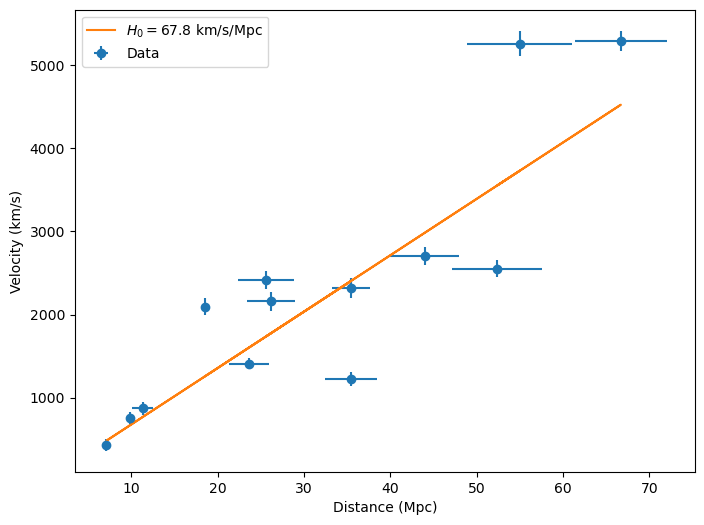

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

dis = data[0::4]
print(dis)
error_dis = data[2::4]
print(error_dis)
velo = data[1::4]
print(velo)
error_velo = data[3::4]
print(error_velo)

print()

# convert sliced lists into numpy arrays
dis = np.array(dis)
velo = np.array(velo)
error_dis = np.array(error_dis)
error_velo = np.array(error_velo)

# Plotting data:
fig, ax = plt.subplots(figsize=(8, 6))

# line (Hubble relation)
H0 = 67.8
hubble_line = H0 * dis

# error bars
ax.errorbar(dis, velo, xerr=error_dis, yerr=error_velo, marker='o', linestyle='', label='Data')

# plot the Hubble line
# Using r'$...$' triggers LaTeX rendering
ax.plot(dis, hubble_line, label=r'$H_0 = {}$ km/s/Mpc'.format(H0))

# formatting
ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Velocity (km/s)')
ax.legend()
plt.show()

In [13]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
